In [5]:
import numpy as np, matplotlib.pyplot as plt

In [6]:
alpha = 1
beta = 1
L = 20
N = 10000
times = []
for _ in range(N):
    i = 0
    t = 0
    while i < L:
        if i == 0:
            rate = alpha
            t += np.random.exponential(1 / rate)
            i += 1
        else:
            rate = alpha + beta
            t += np.random.exponential(1 / rate)

            if np.random.rand() < alpha / rate:
                i += 1
            else:
                i -= 1
    times.append(t)
times = np.array(times)
simulated_mean = np.mean(times)
simulated_variance = np.var(times, ddof=1)
theoretical_mean = L * (L + 1) / (2 * alpha)
print("N =", N)
print("Simulated mean m_0 =", simulated_mean)
print("Theoretical mean m_0 =", theoretical_mean)
print("Difference =", abs(simulated_mean - theoretical_mean))
print("Sample variance =", simulated_variance)

N = 10000
Simulated mean m_0 = 209.38788242546556
Theoretical mean m_0 = 210.0
Difference = 0.6121175745344374
Sample variance = 29531.33147835124


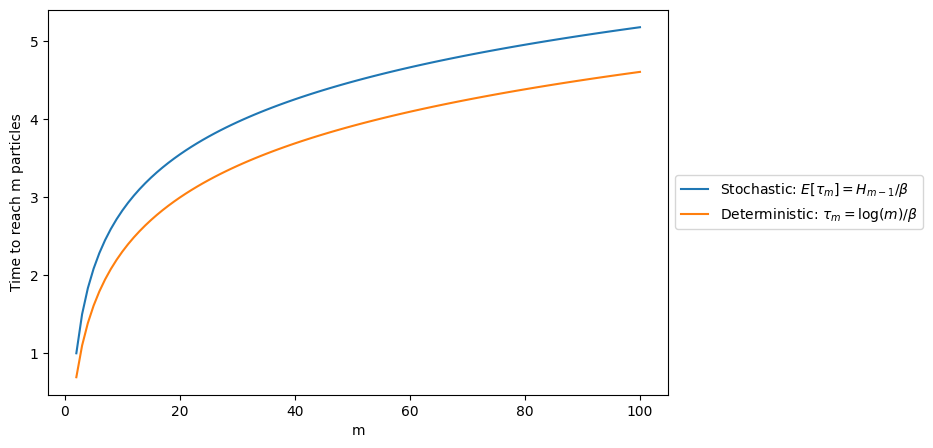

In [11]:
beta = 1
m_values = np.arange(2, 101)
expected_tau = []
deterministic_tau = []
for m in m_values:
    harmonic_sum = sum(1 / k for k in range(1, m))
    expected_tau.append(harmonic_sum / beta)
    deterministic_tau.append(np.log(m) / beta)
plt.figure(figsize=(8, 5))
plt.plot(m_values, expected_tau, label=r"Stochastic: $E[\tau_m]=H_{m-1}/\beta$")
plt.plot(m_values, deterministic_tau, label=r"Deterministic: $\tau_m=\log(m)/\beta$")
plt.xlabel("m")
plt.ylabel("Time to reach m particles")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/4_1.png', dpi = 300, bbox_inches = 'tight')